In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


FINAL DATA (Mean, SD, p-value):

    Launch_Power_dBm  mean_BER   std_BER      Case       p_value
0              -14.0  0.000730  0.000026  Baseline           NaN
1              -12.0  0.000456  0.000037  Baseline           NaN
2              -10.0  0.000338  0.000028  Baseline           NaN
3               -8.0  0.000290  0.000022  Baseline           NaN
4               -6.0  0.000242  0.000017  Baseline           NaN
5               -4.0  0.000221  0.000014  Baseline           NaN
6               -2.0  0.000206  0.000014  Baseline           NaN
7                0.0  0.000201  0.000014  Baseline           NaN
8                2.0  0.000208  0.000013  Baseline           NaN
9                4.0  0.000238  0.000019  Baseline           NaN
10               6.0  0.000423  0.000008  Baseline           NaN
11               8.0  0.001504  0.000011  Baseline           NaN
24             -14.0  0.000636  0.000047        MP  7.438592e-03
25             -12.0  0.000379  0.000019        MP  6.10

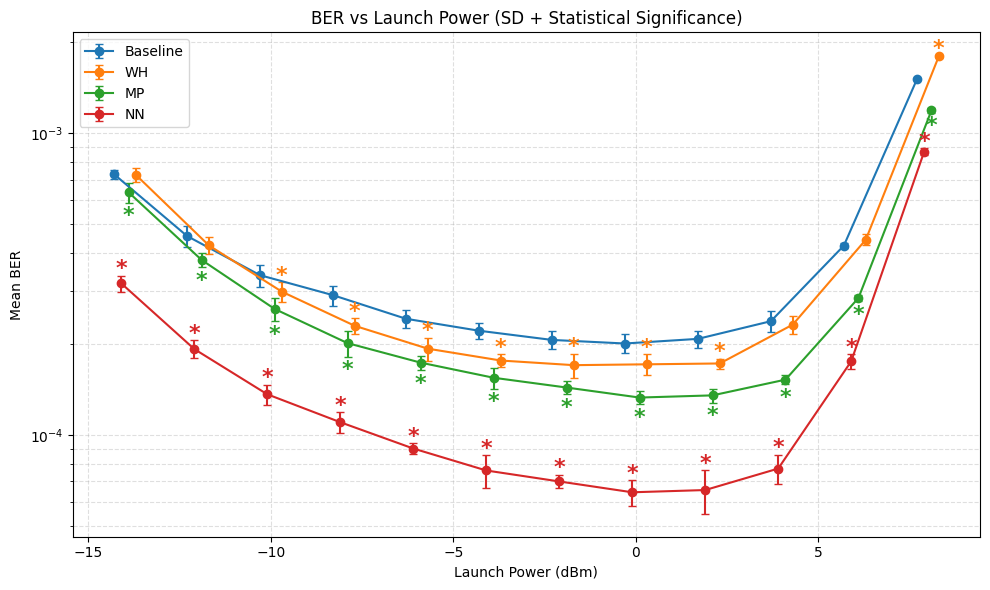

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind

FILES = {
    "Baseline": "FINAL_results_NoDPD_BER_vs_Launch_Power.csv",
    "NN": "FINAL_results_DPD_BER_vs_Launch_Power.csv",
    "MP": "FINAL_results_DPD_MP_BER_vs_launch_power.csv",
    "WH": "FINAL_results_DPD_WH_BER_vs_Launch_Power.csv",
}

BASE_DIR = Path.cwd()

# -----------------------------
# Load data
# -----------------------------
dfs = {}

for case, file in FILES.items():
    df = pd.read_csv(BASE_DIR / file)

    if "P_launch_dBm" in df.columns:
        df = df.rename(columns={"P_launch_dBm": "Launch_Power_dBm"})
    elif "Launch Power" in df.columns:
        df = df.rename(columns={"Launch Power": "Launch_Power_dBm"})

    dfs[case] = df

# -----------------------------
# Compute mean + SD
# -----------------------------
summaries = []

for case, df in dfs.items():
    summary = (
        df.groupby("Launch_Power_dBm")
        .agg(
            mean_BER=("BER", "mean"),
            std_BER=("BER", "std"),
        )
        .reset_index()
    )

    summary["Case"] = case
    summaries.append(summary)

summary_df = pd.concat(summaries)

# -----------------------------
# T-tests vs baseline
# -----------------------------
results = []

powers = sorted(dfs["Baseline"]["Launch_Power_dBm"].unique())

for power in powers:

    baseline_vals = dfs["Baseline"][
        dfs["Baseline"]["Launch_Power_dBm"] == power
    ]["BER"]

    for method in ["NN", "MP", "WH"]:

        method_vals = dfs[method][
            dfs[method]["Launch_Power_dBm"] == power
        ]["BER"]

        _, p_value = ttest_ind(baseline_vals, method_vals, equal_var=False)

        results.append({
            "Launch_Power_dBm": power,
            "Case": method,
            "p_value": p_value
        })

pvals_df = pd.DataFrame(results)

# Merge everything
final_df = summary_df.merge(
    pvals_df,
    on=["Launch_Power_dBm", "Case"],
    how="left"
)

print("\nFINAL DATA (Mean, SD, p-value):\n")
print(final_df.sort_values(["Case", "Launch_Power_dBm"]))

# -----------------------------
# Plot (SD error bars + stars)
# -----------------------------
offsets = {
    "Baseline": -0.3,
    "NN": -0.1,
    "MP": 0.1,
    "WH": 0.3,
}

colors = {
    "Baseline": "tab:blue",
    "NN": "tab:red",
    "MP": "tab:green",
    "WH": "tab:orange",
}

y_offsets = {
    "NN": 1.1,   # above
    "WH": 1.1,   # above
    "MP": 0.8,   # below
}

plt.figure(figsize=(10, 6))

for case in ["Baseline", "WH", "MP", "NN"]:
    data = final_df[final_df["Case"] == case].sort_values("Launch_Power_dBm")

    x = data["Launch_Power_dBm"] + offsets[case]

    plt.errorbar(
        x,
        data["mean_BER"],
        yerr=data["std_BER"],
        marker="o",
        capsize=3,
        label=case,
        color=colors[case],
    )

    # Add stars for statistically significant DPD methods only
    if case != "Baseline":
        for _, row in data.iterrows():
            if pd.notna(row["p_value"]) and row["p_value"] < 0.05:

                mean = row["mean_BER"]
                std = row["std_BER"]

                if case in ["NN", "WH"]:  # stars ABOVE
                    y_pos = (mean + std) * 1.05

                elif case == "MP":        # stars BELOW
                    y_pos = max((mean - std) * 0.9, 1e-12)  # avoid log issues

                plt.text(
                    row["Launch_Power_dBm"] + offsets[case],
                    y_pos,
                    "*",
                    color=colors[case],
                    ha="center",
                    va="center",
                    fontsize=16,
                    fontweight="bold",
                )

plt.yscale("log")
plt.xlabel("Launch Power (dBm)")
plt.ylabel("Mean BER")
plt.title("BER vs Launch Power (SD + Statistical Significance)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("ber_sd_with_significance.png", dpi=300)
plt.show()

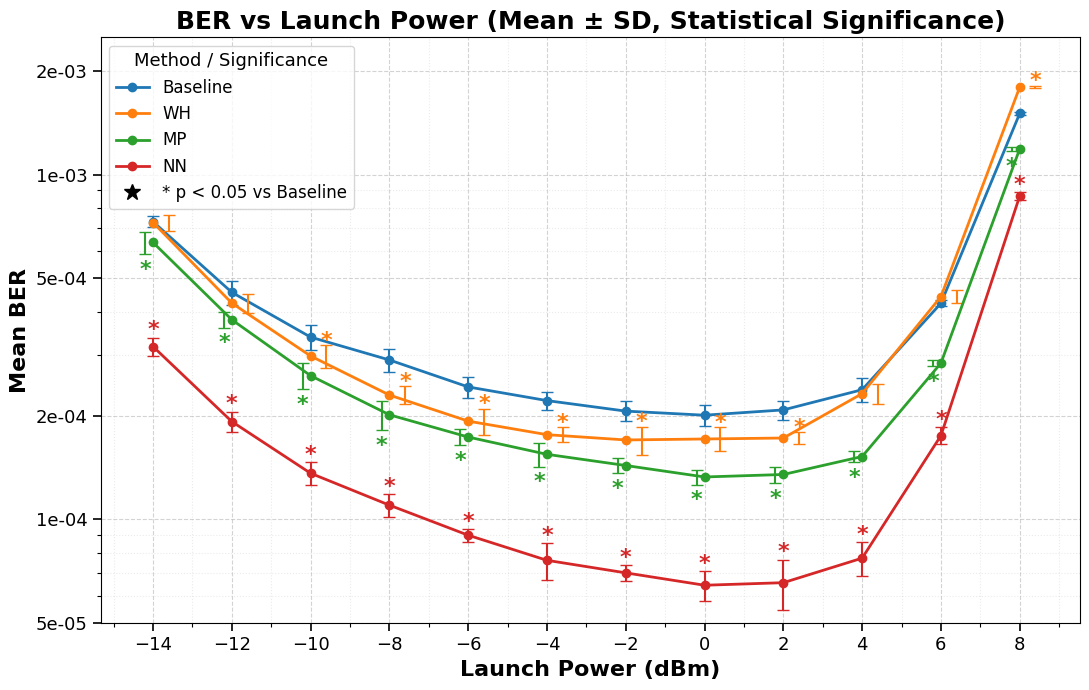

In [39]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, FuncFormatter

# -----------------------------
# Plot settings
# -----------------------------
offsets = {
    "Baseline": 0,
    "NN": 0,
    "MP": -0.2,
    "WH": 0.4,
}

colors = {
    "Baseline": "tab:blue",
    "NN": "tab:red",
    "MP": "tab:green",
    "WH": "tab:orange",
}

plt.figure(figsize=(11, 7))
ax = plt.gca()

# -----------------------------
# Plot curves
# -----------------------------
for case in ["Baseline", "WH", "MP", "NN"]:
    data = final_df[final_df["Case"] == case].sort_values("Launch_Power_dBm")

    x_true = data["Launch_Power_dBm"]
    x_err = data["Launch_Power_dBm"] + offsets[case]

    # Actual mean line and markers at TRUE launch powers
    ax.plot(
        x_true,
        data["mean_BER"],
        marker="o",
        markersize=6,
        linewidth=2,
        label=case,
        color=colors[case],
    )

    # Error bars only, slightly offset
    ax.errorbar(
        x_err,
        data["mean_BER"],
        yerr=data["std_BER"],
        fmt="none",
        capsize=4,
        elinewidth=1.5,
        color=colors[case],
    )

       # Add stars for statistically significant DPD methods only
    if case != "Baseline":
        for _, row in data.iterrows():
            if pd.notna(row["p_value"]) and row["p_value"] < 0.05:

                mean = row["mean_BER"]
                std = row["std_BER"]

                if case == "NN":  # stars ABOVE
                    y_pos = (mean + std) * 1.05
                
                elif case == "WH":  # stars ABOVE
                    y_pos = (mean + std) * 1.03

                elif case == "MP":        # stars BELOW
                    y_pos = max((mean - std) * 0.9, 1e-12)  # avoid log issues

                plt.text(
                    row["Launch_Power_dBm"] + offsets[case],
                    y_pos,
                    "*",
                    color=colors[case],
                    ha="center",
                    va="center",
                    fontsize=16,
                    fontweight="bold",
                )


# -----------------------------
# Axis formatting
# -----------------------------
ax.set_yscale("log")
ax.set_ylim(5e-5, 2.5e-3)

ax.set_xlabel("Launch Power (dBm)", fontsize=16, fontweight="bold")
ax.set_ylabel("Mean BER", fontsize=16, fontweight="bold")
ax.set_title(
    "BER vs Launch Power (Mean ± SD, Statistical Significance)",
    fontsize=18,
    fontweight="bold"
)

# X-axis labels
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(MultipleLocator(1))

# Cleaner y-axis labels
yticks = [5e-5, 1e-4, 2e-4, 5e-4, 1e-3, 2e-3]
ax.set_yticks(yticks)

def sci_format(y, pos):
    return f"{y:.0e}"

ax.yaxis.set_major_formatter(FuncFormatter(sci_format))

ax.tick_params(axis="both", which="major", labelsize=13, width=1.2, length=6)
ax.tick_params(axis="both", which="minor", labelsize=11, width=0.8, length=3)

ax.grid(True, which="major", linestyle="--", alpha=0.55)
ax.grid(True, which="minor", linestyle=":", alpha=0.25)

# -----------------------------
# Legend including asterisk
# -----------------------------
handles, labels = ax.get_legend_handles_labels()

star_handle = Line2D(
    [], [],
    color="black",
    marker="*",
    linestyle="None",
    markersize=12,
    label="* p < 0.05 vs Baseline"
)

handles.append(star_handle)

ax.legend(
    handles=handles,
    fontsize=12,
    title="Method / Significance",
    title_fontsize=13,
    loc="best"
)

plt.tight_layout()
plt.savefig("ber_sd_with_significance_clean.png", dpi=300)
plt.show()